# SEVA testing

#### 1. Get data from dataloader.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from seva.data.mvh_dataloader import MVHumanNetDataset
from torch.utils.data import DataLoader

# load dataset + dataloader
def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

dataset = MVHumanNetDataset(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=8,
    step_size=60,
    only_include=expand_only_include("100010-100010"),
    preload_path="/workspace/datasetvol/mvhuman_data/mv_captures/preloaded_filepaths.json",
    synthetic_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    random_crop=False,
    maximal_crop=True,
    use_inconsistent=True,
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

100010 100010
Loading preloaded filepaths...


Loading scenes: 100%|██████████| 2749/2749 [00:00<00:00, 395043.74it/s]


Loading preloaded filepaths completed!
MVHN::init done!


### 2. Load model and get logged config & checkpoint.

In [3]:
# INPUT: logdir that contains the model checkpoint + config
from omegaconf import OmegaConf
from sgm.util import instantiate_from_config
import os

# required inputs
log_path = "/workspace/stonevol/logs/2025-09-04T23-54-11_example_training-overfit-r256-512-lr-5"
# log_path = "/workspace/stonevol/logs/2025-08-27T12-30-30_example_training-seva-phase1"
checkpoint_name = "epoch=024999.ckpt"
# checkpoint_name = "last.ckpt"

# get config
filename_base = os.path.basename(log_path).split("_")[0]
run_config = OmegaConf.load(f"{log_path}/configs/{filename_base}-project.yaml")
ckpt_path = f"{log_path}/checkpoints/{checkpoint_name}"

model_config = run_config.model
# parameters to change (from config)
model_config.params.sampler_config.params.guider_config.params.cfg_min = 1.0

# pretty print for debugging
# import pprint
# pprint.pprint(OmegaConf.to_container(model_config))

In [7]:

from sgm.models.diffusion import DiffusionEngine

engine = instantiate_from_config(run_config.model)
engine.init_from_ckpt(ckpt_path)
engine.eval()

Initialized embedder #0: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #1: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #2: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #3: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #4: SevaFrozenOpenCLIPImageEmbedder with 683800065 params. Trainable: False
Restored from /workspace/stonevol/logs/2025-09-04T23-54-11_example_training-overfit-r256-512-lr-5/checkpoints/epoch=024999.ckpt with 0 missing and 0 unexpected keys


DiffusionEngine(
  (model): SevaWrapper(
    (diffusion_model): SevaLoRAWrapper(
      (seva_model): Seva(
        (time_embed): Sequential(
          (0): Linear(in_features=320, out_features=1280, bias=True)
          (1): SiLU()
          (2): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (input_blocks): ModuleList(
          (0): TimestepEmbedSequential(
            (0): Conv2d(16, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (1-2): 2 x TimestepEmbedSequential(
            (0): ResBlock(
              (in_layers): Sequential(
                (0): GroupNorm32(32, 320, eps=1e-05, affine=True)
                (1): SiLU()
                (2): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
              (emb_layers): Sequential(
                (0): SiLU()
                (1): Linear(in_features=1280, out_features=320, bias=True)
              )
              (dense_emb_layers): Sequential(


### 3. Run inference using our proposed model
Note that we are still able to change the CFG after instantiating the model.

In [8]:
batch = next(iter(loader))

In [9]:
import torch 
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

def all_items_to_gpu(batch):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to("cuda")
    return batch

def cfg_test(batch, engine, scales=[0.0, 0.5, 1.0, 1.2, 2.0, 3.0, 5.0, 8.0]):
    for scale in scales:
        batch_copy = batch.copy()
        samples = run_step(batch_copy, engine, scale=scale)
        decoded_samples = normalize_tensor(engine.decode_first_stage(samples)).to("cpu")
        print(f"scale: {scale}")
        _ = show_tensor_batch(decoded_samples, masks=(batch_copy["ref_mask"].to("cpu")).squeeze(0))

def run_step(batch, engine, scale=1.0):
    batch = all_items_to_gpu(batch)
    engine = engine.to("cuda")
    samples = engine.infer(batch, scale=scale).squeeze(0)
    return samples

batch_ = batch.copy()
samples = run_step(batch_, engine, scale=1.0)
# cfg_test(batch_, engine, scales=[0.0, 0.5, 1.0, 1.2, 2.0, 3.0, 5.0, 8.0])

In [16]:
os.makedirs("output_samples", exist_ok=True)
torch.save(batch['c2w'], "output_samples/c2w.pt")
torch.save(batch['K'], "output_samples/K.pt")
torch.save(batch['ref_mask'], "output_samples/ref_mask.pt")

tensor([[ True, False, False, False, False, False, False, False]])
tensor([[True, True, True, True, True, True, True, True]])


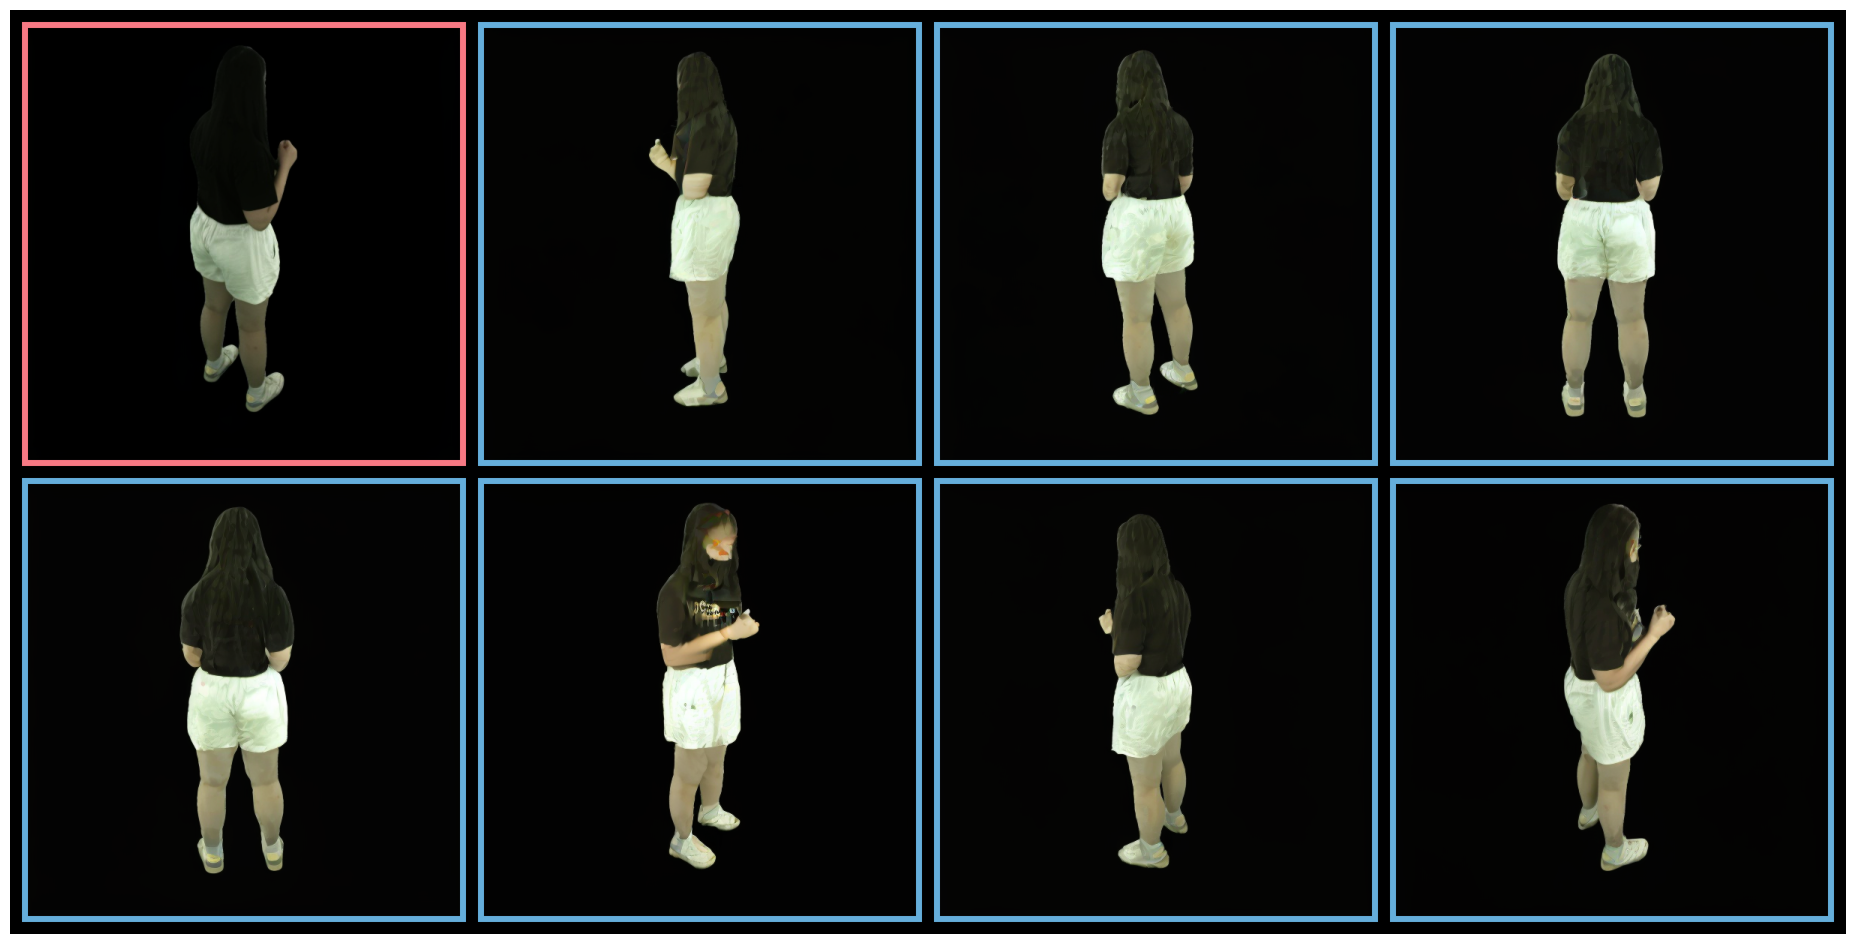

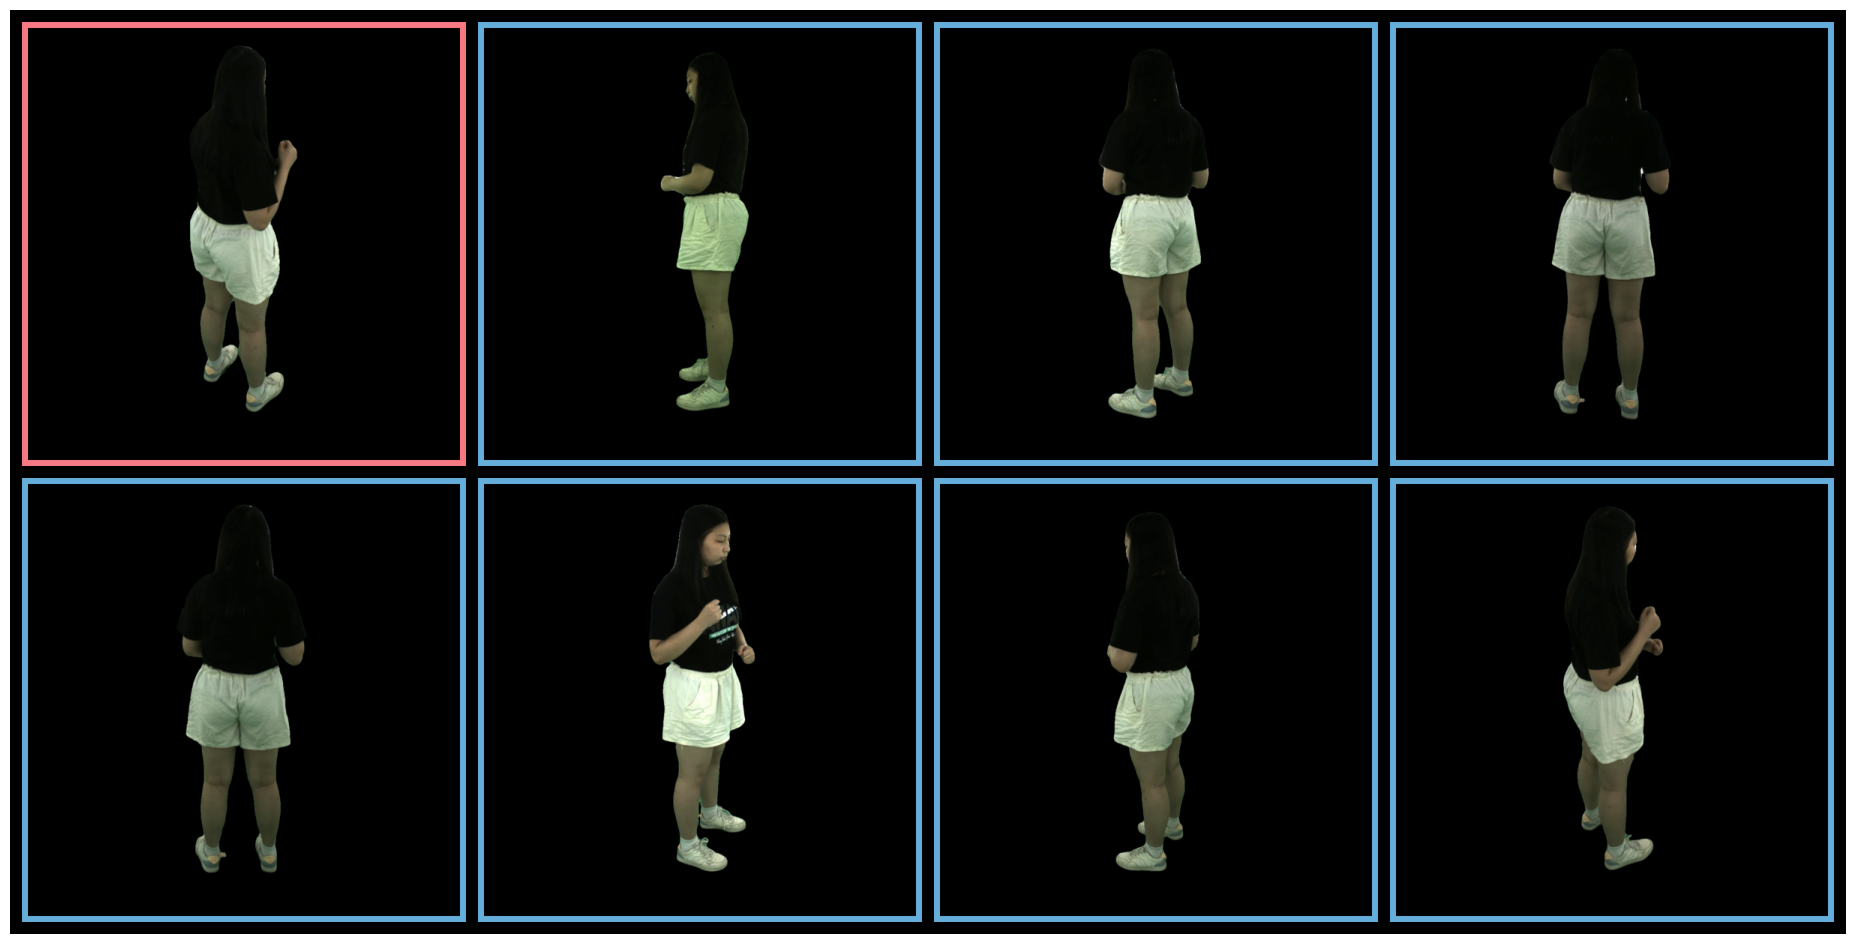

In [13]:
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

def save_image_batch(batch, samples, output_dir="output_samples"):
    # saves resulting images to a directory
    # reference image (mask) will be called "ref.png"
    # input images will be called "input_<index>.png"
    # output images will be called "target_<index>.png"
    os.makedirs(output_dir, exist_ok=True)
    
    import torchvision.utils as vutils
    
    # Save reference mask
    ref_mask = batch["ref_mask"].squeeze(0)  # Remove batch dimension
    samples = samples.squeeze(0) if samples.dim() == 4 else samples  # Handle batch dimension if present
    for i in range(samples.shape[0]):
        name = f"target_{i}.png"
        if ref_mask[i] == 1:
            name = f"ref.png"

        vutils.save_image(samples[i], os.path.join(output_dir, name))

decoded_samples = normalize_tensor(engine.decode_first_stage(samples)).to("cpu")
print(batch["ref_mask"])
print(batch["mask"])
_ = show_tensor_batch(decoded_samples, masks=(batch["ref_mask"].to("cpu")).squeeze(0))
_ = show_tensor_batch(normalize_tensor(batch["frames"].squeeze(0)), masks=(batch["ref_mask"].to("cpu")).squeeze(0))
save_image_batch(batch, decoded_samples)